# 🌾 CropLogic AI — Notebook 02
### Model Training & Evaluation
---
**What this notebook does:**
1. Load the feature dataset from Notebook 01
2. Split data into train and test sets (two strategies)
3. Scale features
4. Train 4 models + 1 weighted ensemble
5. Evaluate each model with R², RMSE, MAE
6. Plot results and feature importance
7. Save all models to disk

**Input:** `usa_maize_features.csv`  
**Output:** `agriAI_models.pkl` — trained models ready for use

## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ── Dark theme ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1923',
    'axes.facecolor':   '#0f1923',
    'axes.edgecolor':   '#2a3f52',
    'axes.labelcolor':  '#c8d8e8',
    'text.color':       '#c8d8e8',
    'xtick.color':      '#8aa0b0',
    'ytick.color':      '#8aa0b0',
    'grid.color':       '#1e2e3e',
    'grid.linewidth':   0.5,
    'figure.dpi':       120,
    'font.size':        11,
})

C = {
    'green':  '#00d4aa',
    'orange': '#ff6b35',
    'blue':   '#4fc3f7',
    'yellow': '#ffd166',
    'purple': '#a78bfa',
    'red':    '#f87171',
}

print('✅ Imports ready')

✅ Imports ready


---
## 1. Load Data & Define Features

In [2]:
# Load the feature dataset produced by Notebook 01
df = pd.read_csv('usa_maize_features.csv')

print('=== DATASET LOADED ===')
print(f'  Rows:    {len(df):,}')
print(f'  Columns: {df.shape[1]}')

=== DATASET LOADED ===
  Rows:    62,400
  Columns: 33


In [3]:
# These are the same 25 features we built in Notebook 01.
# The target variable is yield_kg_ha — this is what the model tries to predict.

ALL_FEATURES = [
    'tas_C', 'pr_mm',
    'tas_sq', 'pr_log', 'aridity_index',
    'tas_anomaly_county', 'pr_anomaly_county',
    'soil_ph_topsoil', 'soil_soc_percent',
    'soil_clay_percent', 'soil_sand_percent', 'soil_silt_percent',
    'whc_proxy', 'ph_dev_opt',
    'lat_norm', 'dist_corn_belt',
    'years_since_1961', 'trend_linear', 'trend_sq', 'trend_sqrt',
    'tas_x_pr', 'heat_drought_stress',
    'yield_lag1',
    'state_code', 'decade',
]

TARGET = 'yield_kg_ha'

X = df[ALL_FEATURES]
y = df[TARGET]

print(f'✅ Feature matrix: {X.shape[0]:,} rows × {X.shape[1]} features')
print(f'   Target range:   {y.min():.0f} – {y.max():.0f} kg/ha')

✅ Feature matrix: 62,400 rows × 25 features
   Target range:   1721 – 14909 kg/ha


---
## 2. Train / Test Splits

We use **two evaluation strategies**:

| Strategy | Train | Test | Purpose |
|---|---|---|---|
| **Temporal split** | 1961–2009 | 2010–2024 | Realistic — can the model predict *future* years it has never seen? |
| **Random split** | 80% random | 20% random | Upper-bound — how well does it do with mixed data? |

The **temporal split is the primary one** — it mirrors real-world use where you train on historical data and predict future seasons.

In [4]:
# Temporal split: train on everything before 2010, test on 2010 onwards
train_mask = df['year'] <= 2009
test_mask  = df['year'] >= 2010

X_train_t = X[train_mask]
y_train_t = y[train_mask]
X_test_t  = X[test_mask]
y_test_t  = y[test_mask]

print('=== TEMPORAL SPLIT ===')
print(f'  Train: {len(X_train_t):,} rows  (years 1961–2009)')
print(f'  Test:  {len(X_test_t):,} rows  (years 2010–2024)')

=== TEMPORAL SPLIT ===
  Train: 47,775 rows  (years 1961–2009)
  Test:  14,625 rows  (years 2010–2024)


In [5]:
# Random split: 80% train / 20% test, shuffled randomly
from sklearn.model_selection import train_test_split

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('=== RANDOM SPLIT ===')
print(f'  Train: {len(X_train_r):,} rows')
print(f'  Test:  {len(X_test_r):,} rows')

=== RANDOM SPLIT ===
  Train: 49,920 rows
  Test:  12,480 rows


---
## 3. Feature Scaling

Ridge Regression requires features to be on the same scale (otherwise variables measured in large numbers dominate).  
Tree-based models (Random Forest, Extra Trees, Gradient Boosting) don't need scaling — but we scale anyway for consistency.

In [6]:
# StandardScaler: shifts each feature to mean=0, std=1
# IMPORTANT: we fit on the TRAIN set only, then apply to both train and test.
# Fitting on test data would be data leakage — the model would be "peeking" at future info.

scaler_t = StandardScaler()
X_train_t_sc = scaler_t.fit_transform(X_train_t)   # fit + transform on train
X_test_t_sc  = scaler_t.transform(X_test_t)         # transform only on test

scaler_r = StandardScaler()
X_train_r_sc = scaler_r.fit_transform(X_train_r)
X_test_r_sc  = scaler_r.transform(X_test_r)

print('✅ Scaling done')
print(f'   Train mean (should be ~0): {X_train_t_sc.mean():.4f}')
print(f'   Train std  (should be ~1): {X_train_t_sc.std():.4f}')

✅ Scaling done
   Train mean (should be ~0): 0.0000
   Train std  (should be ~1): 1.0000


---
## 4. Train the Models

We train **4 individual models** + **1 weighted ensemble** that combines their predictions.

| Model | Type | Why we include it |
|---|---|---|
| **Ridge Regression** | Linear | Simple, interpretable baseline |
| **Random Forest** | Tree ensemble (bagging) | Robust, handles non-linear patterns |
| **Extra Trees** | Tree ensemble (random splits) | Faster than RF, less overfitting |
| **Gradient Boosting** | Tree ensemble (boosting) | Usually the most accurate single model |
| **Weighted Ensemble** | Meta-combiner | Blends all 4 — best final predictor |

In [7]:
# ── Model 1: Ridge Regression ──────────────────────────────────────────
# Linear model. RidgeCV automatically picks the best regularisation strength (alpha)
# from the list we give it using cross-validation.
# alpha controls how much we penalise large coefficients to prevent overfitting.

ridge = RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0])
ridge.fit(X_train_t_sc, y_train_t)

print(f'✅ Ridge trained  |  Best alpha: {ridge.alpha_}')

✅ Ridge trained  |  Best alpha: 0.1


In [8]:
# ── Model 2: Random Forest ─────────────────────────────────────────────
# Builds 200 decision trees on random subsets of the data, then averages their predictions.
# n_estimators = number of trees (more = more stable, but slower)
# n_jobs=-1    = use all CPU cores to train in parallel

rf = RandomForestRegressor(n_estimators=200, max_features='sqrt',
                            random_state=42, n_jobs=-1)
rf.fit(X_train_t, y_train_t)

print('✅ Random Forest trained')

✅ Random Forest trained


In [9]:
# ── Model 3: Extra Trees ───────────────────────────────────────────────
# Similar to Random Forest, but uses fully random split points at each node.
# This makes it faster and often reduces overfitting compared to Random Forest.

et = ExtraTreesRegressor(n_estimators=200, max_features='sqrt',
                          random_state=42, n_jobs=-1)
et.fit(X_train_t, y_train_t)

print('✅ Extra Trees trained')

✅ Extra Trees trained


In [10]:
# ── Model 4: Gradient Boosting ─────────────────────────────────────────
# Builds trees sequentially — each new tree corrects the errors of the previous ones.
# learning_rate = how much each tree contributes (smaller = more careful, needs more trees)
# max_depth     = how complex each individual tree is

gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                max_depth=5, random_state=42)
gb.fit(X_train_t, y_train_t)

print('✅ Gradient Boosting trained')

✅ Gradient Boosting trained


---
## 5. Evaluate on Temporal Split

We measure three metrics for each model:
- **R²** — proportion of variance explained (1.0 = perfect, 0.0 = no better than guessing the mean)
- **RMSE** — average error in kg/ha (same units as yield, lower = better)
- **MAE** — average absolute error in kg/ha (less sensitive to large outliers than RMSE)

In [11]:
# Helper function: evaluate a model and return its metrics
def evaluate(model, X_test, y_test, scaled=False, X_train_sc=None, y_train=None):
    preds = model.predict(X_test)
    r2   = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)
    return {'R2': r2, 'RMSE': rmse, 'MAE': mae, 'preds': preds}

print('✅ Evaluation helper ready')

✅ Evaluation helper ready


In [12]:
# Evaluate all 4 models on the temporal test set (2010-2024)

results_t = {
    'Ridge':    evaluate(ridge, X_test_t_sc, y_test_t),
    'RandomForest': evaluate(rf, X_test_t, y_test_t),
    'ExtraTrees':   evaluate(et, X_test_t, y_test_t),
    'GradBoost':    evaluate(gb, X_test_t, y_test_t),
}

print('=== TEMPORAL SPLIT RESULTS (2010–2024) ===')
print(f'  {"Model":<18} {"R²":>8} {"RMSE":>10} {"MAE":>10}')
print('  ' + '-' * 50)
for name, res in results_t.items():
    print(f'  {name:<18} {res["R2"]:>8.4f} {res["RMSE"]:>10.1f} {res["MAE"]:>10.1f}')

=== TEMPORAL SPLIT RESULTS (2010–2024) ===
  Model                    R²       RMSE        MAE
  --------------------------------------------------
  Ridge                0.0150     1576.0     1317.2
  RandomForest         0.4959     1127.5      893.6
  ExtraTrees           0.4997     1123.2      892.0
  GradBoost            0.5177     1102.8      856.4


In [13]:
# ── Weighted Ensemble ──────────────────────────────────────────────────
# We combine the 4 models by weighting each one by its R² score.
# Better-performing models get more say in the final prediction.

weights = np.array([results_t[m]['R2'] for m in ['Ridge', 'RandomForest', 'ExtraTrees', 'GradBoost']])
weights = np.clip(weights, 0, None)       # ignore any model with negative R²
weights = weights / weights.sum()         # normalise so they sum to 1

# Weighted average of the 4 sets of predictions
ensemble_preds_t = (
    weights[0] * results_t['Ridge']['preds'] +
    weights[1] * results_t['RandomForest']['preds'] +
    weights[2] * results_t['ExtraTrees']['preds'] +
    weights[3] * results_t['GradBoost']['preds']
)

ens_r2   = r2_score(y_test_t, ensemble_preds_t)
ens_rmse = np.sqrt(mean_squared_error(y_test_t, ensemble_preds_t))
ens_mae  = mean_absolute_error(y_test_t, ensemble_preds_t)

results_t['Ensemble'] = {'R2': ens_r2, 'RMSE': ens_rmse, 'MAE': ens_mae, 'preds': ensemble_preds_t}

print('=== ENSEMBLE WEIGHTS ===')
for name, w in zip(['Ridge', 'RandomForest', 'ExtraTrees', 'GradBoost'], weights):
    print(f'  {name:<18}: {w:.3f}')
print(f'\n  Ensemble R²:   {ens_r2:.4f}')
print(f'  Ensemble RMSE: {ens_rmse:.1f} kg/ha')
print(f'  Ensemble MAE:  {ens_mae:.1f} kg/ha')

=== ENSEMBLE WEIGHTS ===
  Ridge             : 0.010
  RandomForest      : 0.324
  ExtraTrees        : 0.327
  GradBoost         : 0.339

  Ensemble R²:   0.5239
  Ensemble RMSE: 1095.7 kg/ha
  Ensemble MAE:  862.6 kg/ha


In [14]:
# Also evaluate on the random split for comparison

results_r = {
    'Ridge':       evaluate(ridge, X_test_r_sc, y_test_r),
    'RandomForest':evaluate(rf,    X_test_r,    y_test_r),
    'ExtraTrees':  evaluate(et,    X_test_r,    y_test_r),
    'GradBoost':   evaluate(gb,    X_test_r,    y_test_r),
}

ensemble_preds_r = (
    weights[0] * results_r['Ridge']['preds'] +
    weights[1] * results_r['RandomForest']['preds'] +
    weights[2] * results_r['ExtraTrees']['preds'] +
    weights[3] * results_r['GradBoost']['preds']
)
results_r['Ensemble'] = {
    'R2':   r2_score(y_test_r, ensemble_preds_r),
    'RMSE': np.sqrt(mean_squared_error(y_test_r, ensemble_preds_r)),
    'MAE':  mean_absolute_error(y_test_r, ensemble_preds_r),
    'preds': ensemble_preds_r
}

print('=== RANDOM SPLIT RESULTS ===')
print(f'  {"Model":<18} {"R²":>8} {"RMSE":>10} {"MAE":>10}')
print('  ' + '-' * 50)
for name, res in results_r.items():
    print(f'  {name:<18} {res["R2"]:>8.4f} {res["RMSE"]:>10.1f} {res["MAE"]:>10.1f}')

=== RANDOM SPLIT RESULTS ===
  Model                    R²       RMSE        MAE
  --------------------------------------------------
  Ridge                0.7520     1259.3      998.3
  RandomForest         0.9494      568.7      308.0
  ExtraTrees           0.9534      545.8      207.3
  GradBoost            0.9312      663.1      458.6
  Ensemble             0.9497      566.9      323.7


In [15]:
# ── 5-Fold Cross-Validation ────────────────────────────────────────────
# Splits the full dataset into 5 parts, trains on 4, tests on 1, repeats 5 times.
# Gives us a more reliable accuracy estimate and checks for overfitting.

print('Running 5-fold cross-validation (this may take a minute)...')

X_sc_full = StandardScaler().fit_transform(X)

cv_scores = {
    'Ridge':        cross_val_score(RidgeCV(), X_sc_full, y, cv=5, scoring='r2'),
    'RandomForest': cross_val_score(RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), X, y, cv=5, scoring='r2'),
    'ExtraTrees':   cross_val_score(ExtraTreesRegressor(n_estimators=100,   random_state=42, n_jobs=-1), X, y, cv=5, scoring='r2'),
    'GradBoost':    cross_val_score(GradientBoostingRegressor(n_estimators=100, random_state=42), X, y, cv=5, scoring='r2'),
}

print('\n=== 5-FOLD CROSS-VALIDATION R² ===')
print(f'  {"Model":<18} {"Mean R²":>10} {"Std":>8}')
print('  ' + '-' * 40)
for name, scores in cv_scores.items():
    print(f'  {name:<18} {scores.mean():>10.4f} {scores.std():>8.4f}')

Running 5-fold cross-validation (this may take a minute)...

=== 5-FOLD CROSS-VALIDATION R² ===
  Model                 Mean R²      Std
  ----------------------------------------
  Ridge                  0.8950   0.0057
  RandomForest           0.9403   0.0076
  ExtraTrees             0.9391   0.0119
  GradBoost              0.9301   0.0096


---
## 6. Visualise Results

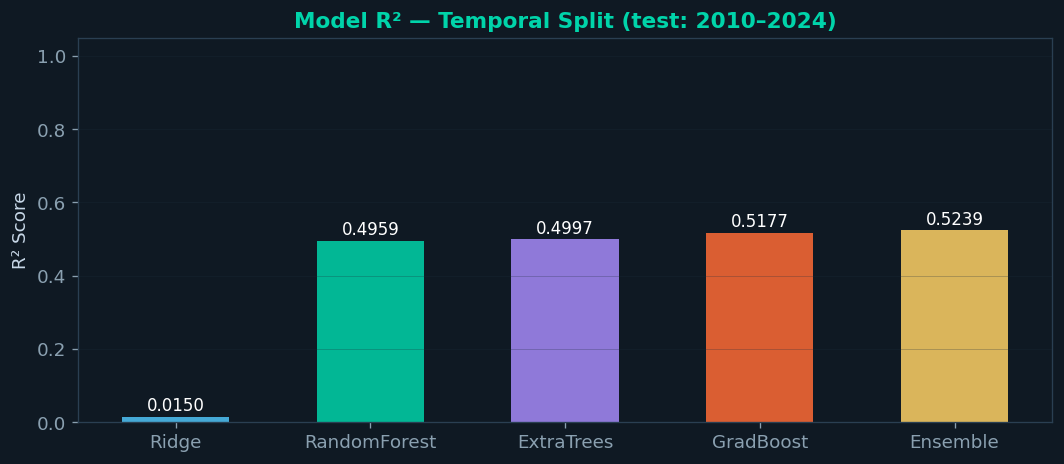

In [16]:
# Chart 1 — R² comparison across models (temporal split)
# Higher bar = better model

model_names = list(results_t.keys())
r2_scores   = [results_t[m]['R2'] for m in model_names]
bar_colors  = [C['blue'], C['green'], C['purple'], C['orange'], C['yellow']]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(model_names, r2_scores, color=bar_colors, alpha=0.85, width=0.55)

for bar, val in zip(bars, r2_scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, color='white')

ax.set_ylim(0, 1.05)
ax.set_ylabel('R² Score')
ax.set_title('Model R² — Temporal Split (test: 2010–2024)',
             color=C['green'], fontsize=13, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_model_r2.png', bbox_inches='tight', facecolor='#0f1923')
plt.show()

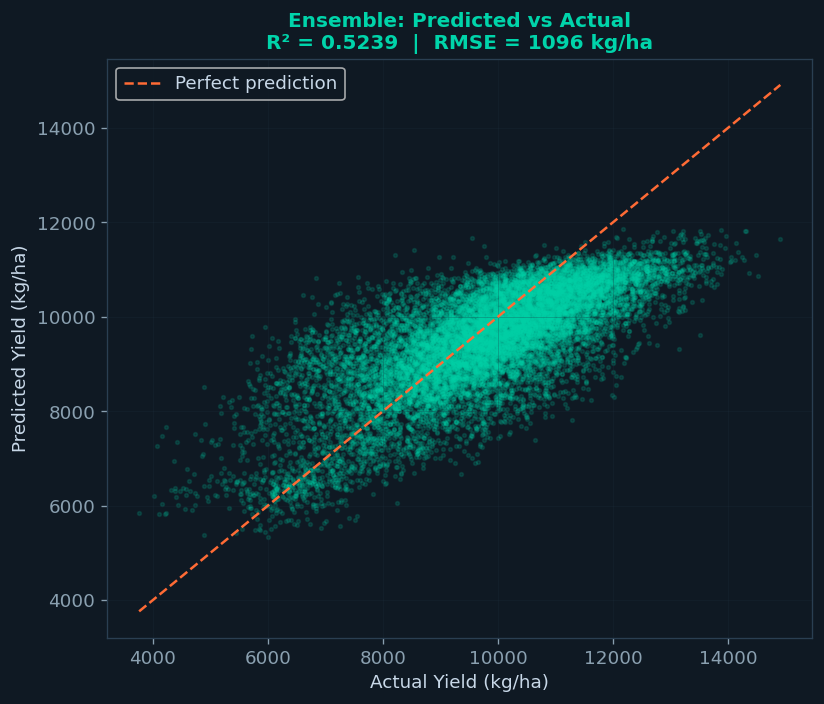

In [17]:
# Chart 2 — Predicted vs Actual yield (Ensemble model, temporal split)
# Points falling on the diagonal line = perfect prediction

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(y_test_t, ensemble_preds_t, alpha=0.15, s=5, color=C['green'])

# Perfect prediction line
lims = [y_test_t.min(), y_test_t.max()]
ax.plot(lims, lims, color=C['orange'], linewidth=1.5, ls='--', label='Perfect prediction')

ax.set_xlabel('Actual Yield (kg/ha)')
ax.set_ylabel('Predicted Yield (kg/ha)')
ax.set_title(f'Ensemble: Predicted vs Actual\nR² = {ens_r2:.4f}  |  RMSE = {ens_rmse:.0f} kg/ha',
             color=C['green'], fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_pred_vs_actual.png', bbox_inches='tight', facecolor='#0f1923')
plt.show()

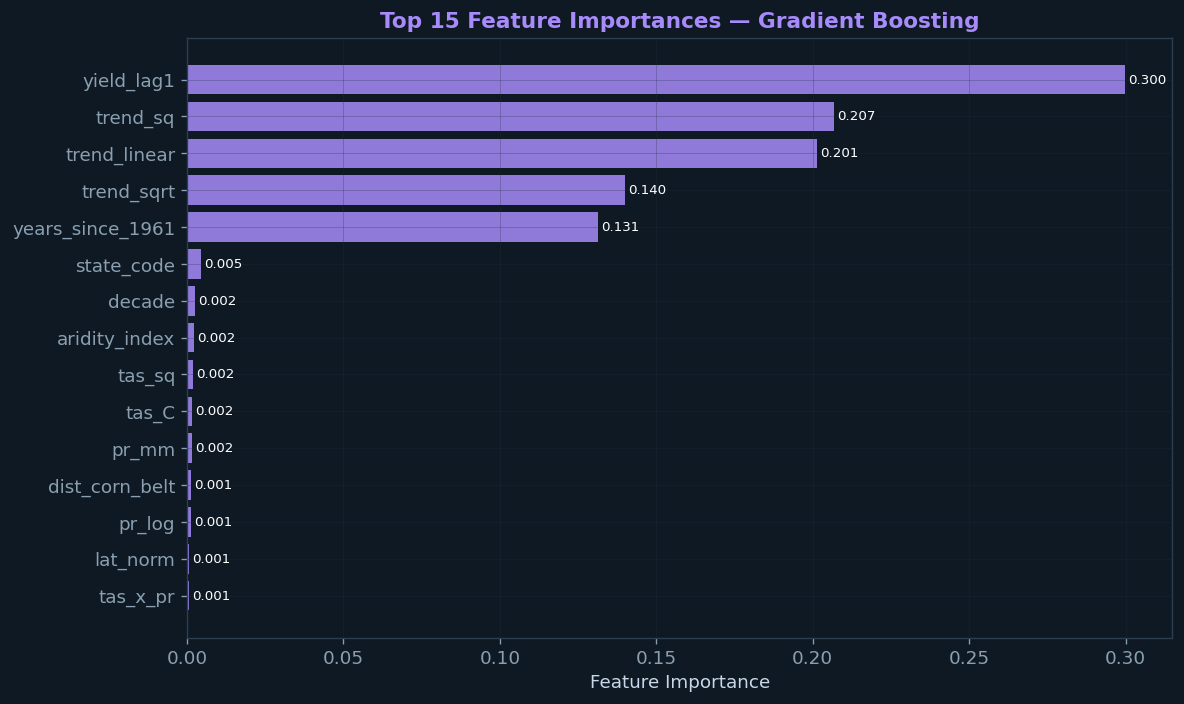

In [18]:
# Chart 3 — Feature importance from Gradient Boosting
# Shows which features the model relied on most when making predictions.
# Higher importance = that feature was more useful for splitting decisions in the trees.

importance = pd.Series(gb.feature_importances_, index=ALL_FEATURES).sort_values(ascending=False)
top15 = importance.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top15.index[::-1], top15.values[::-1], color=C['purple'], alpha=0.85)

for bar, val in zip(bars, top15.values[::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=8, color='white')

ax.set_xlabel('Feature Importance')
ax.set_title('Top 15 Feature Importances — Gradient Boosting',
             color=C['purple'], fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_feature_importance.png', bbox_inches='tight', facecolor='#0f1923')
plt.show()

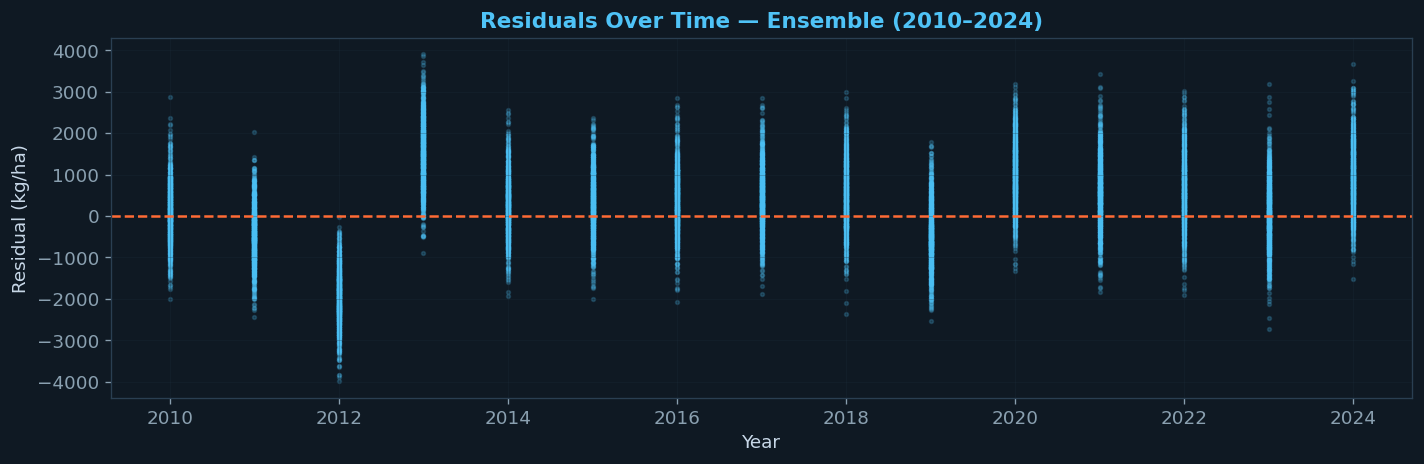

In [19]:
# Chart 4 — Residuals over time (Ensemble model)
# Residual = actual yield - predicted yield
# If the model is good, residuals should be scattered randomly around 0 (no systematic bias).

test_years = df.loc[test_mask, 'year']
residuals  = y_test_t.values - ensemble_preds_t

fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(test_years, residuals, alpha=0.2, s=5, color=C['blue'])
ax.axhline(0, color=C['orange'], linewidth=1.5, ls='--')
ax.set_xlabel('Year')
ax.set_ylabel('Residual (kg/ha)')
ax.set_title('Residuals Over Time — Ensemble (2010–2024)',
             color=C['blue'], fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_residuals.png', bbox_inches='tight', facecolor='#0f1923')
plt.show()

---
## 7. Save Models

In [20]:
# Bundle everything into one dictionary and save to a .pkl file.
# pkl (pickle) is Python's standard format for saving any object to disk.
# We save models, scalers, feature list, weights — everything needed to make predictions later.

model_bundle = {
    # Trained models
    'ridge':  ridge,
    'rf':     rf,
    'et':     et,
    'gb':     gb,

    # Scalers (needed to preprocess new data before predicting)
    'scaler_temporal': scaler_t,
    'scaler_random':   scaler_r,

    # Ensemble weights
    'ensemble_weights': weights,

    # Feature list (so we always know which columns to pass in)
    'features': ALL_FEATURES,

    # Evaluation results for reference
    'results_temporal': {k: {m: v for m, v in res.items() if m != 'preds'}
                         for k, res in results_t.items()},
    'results_random':   {k: {m: v for m, v in res.items() if m != 'preds'}
                         for k, res in results_r.items()},
}

with open('agriAI_models.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)

print('✅ Models saved → agriAI_models.pkl')
print(f'   Contents: ridge, rf, et, gb, 2 scalers, ensemble weights, feature list')
print()
print('Next step → CropAI-03: Soil Assessment')

✅ Models saved → agriAI_models.pkl
   Contents: ridge, rf, et, gb, 2 scalers, ensemble weights, feature list

Next step → CropAI-03: Soil Assessment


---
## ✅ Notebook 02 Complete

| Step | What we did | Output |
|---|---|---|
| Load | Read feature dataset | 62,400 rows × 25 features |
| Split | Temporal (1961–2009 / 2010–2024) + Random (80/20) | 2 train/test pairs |
| Scale | StandardScaler on train, applied to test | Scaled feature matrices |
| Train | Ridge, Random Forest, Extra Trees, Gradient Boosting | 4 trained models |
| Ensemble | Weighted average of 4 models (by R²) | Best predictor |
| Evaluate | R², RMSE, MAE on temporal + random split + 5-fold CV | Metrics table |
| Plots | R² bar chart, predicted vs actual, feature importance, residuals | `fig_*.png` |
| Save | All models + scalers + metadata | `agriAI_models.pkl` |

**Next → CropAI-03: Soil Assessment Module**